In [44]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib as mpl
from urllib.parse import urlparse
import seaborn as sns
import sys
sys.path.append("../")
from src.repo_utils import RepoStatus

df_paper_assessment = pd.read_parquet("../data/02_paper_assessment/references_paper_assessment_pred.parquet.br")
df_repo_assessment = pd.read_parquet("../data/03_repo_assessment/references_repo_assessment_pred.parquet.br")

In [2]:
# Join the two dataframes on PMID for analysis

repo_cols = [
    "PMID",
    "repo_content",
    "repo_status",
    "repo_error",
    "is_empty",
    "contains_readme",
    "readme_purpose_and_outputs",
    "contains_requirements",
    "requirements_dependency_versions",
    "contains_license",
    "sufficient_code_documentation",
    "is_modular_and_structured",
    "implements_tests",
    "fixes_seed_if_stochastic",
    "lists_hardware_requirements",
    "contains_link_to_paper",
    "contains_citation",
    "includes_data_or_sample",
]

df_final = df_paper_assessment.merge(
    df_repo_assessment[repo_cols],
    on="PMID",
    how="left",
    validate="one_to_one",  # optional but recommended
)

In [31]:
df_joined = df_paper_assessment.merge(
    df_repo_assessment,
    on="PMID",
    how="left",
    suffixes=("", "_repo")
)

df_inscope = df_final[df_final["is_match"] == True]

## Repo Provider distribution

In [42]:
# Exclude NA/empty and appendix placeholders
urls = (
    df_inscope["repo_url"]
    .fillna("")
    .astype(str)
    .str.strip()
)
urls = urls[~urls.isin(["", "Appendix", "Appendi", "<NA>"])]

def extract_domain(url):
    # Handle malformed or plain text entries gracefully
    if not (url.startswith("http://") or url.startswith("https://")):
        url = "http://" + url  # helps urlparse handle it
    try:
        parsed = urlparse(url)
        return parsed.netloc
    except Exception:
        return "<invalid>"

domain_series = urls.apply(extract_domain)

# Count proportions by domain
domain_counts = (
    domain_series.value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
    .rename(columns={"repo_url": "domain"})
)

print(domain_counts)

                         domain  proportion
0                    github.com    0.834452
1                       doi.org    0.038031
2                        osf.io    0.035794
3                    zenodo.org    0.013423
4                    gitlab.com    0.011186
5                 codeocean.com    0.004474
6               www.synapse.org    0.004474
7         ehealthinformation.ca    0.004474
8                 qdiabetes.org    0.002237
9                qmortality.org    0.002237
10                gitlab.lrz.de    0.002237
11                 duke.box.com    0.002237
12               www.kamick.org    0.002237
13    www.helmholtz-muenchen.de    0.002237
14         biostat.app.vumc.org    0.002237
15                 figshare.com    0.002237
16             ljzyal.github.io    0.002237
17            data.mendeley.com    0.002237
18               www.github.com    0.002237
19  gitlab.developers.cam.ac.uk    0.002237
20               huggingface.co    0.002237
21             sdr.stanford.edu 

## Code Sharing Status

In [7]:
import pandas as pd

def map_code_sharing_practice(row):
    if not row["is_match"]:
        return None

    status = row["repo_status"]
    repo_empty = row["is_empty"]
    repo_url = row["repo_url"]

    if status == RepoStatus.OK:
        return "Non Empty Repository"
    if status == RepoStatus.EMPTY or repo_empty is True:
        return "Empty Repository"
    if status == RepoStatus.INACCESSIBLE:
        return "Repository Can't Be Accessed"
    if status == RepoStatus.NOT_SUPPORTED:
        return "Repository Provider Not Supported"

    if pd.isna(status) and isinstance(repo_url, str) and repo_url.strip().lower() == "appendix":
        return "Code Shared in Appendix"

    return None


df_final["code_sharing_practice"] = df_final.apply(
    map_code_sharing_practice, axis=1
)

counts = (
    df_final["code_sharing_practice"]
    .dropna()
    .value_counts()
)

total = counts.sum()
summary = counts.astype(str) + " (" + (counts / total * 100).round(1).astype(str) + "%)"

print(f"\nCode sharing practice counts (n={total}):\n")
print(summary.to_string())


Code sharing practice counts (n=522):

code_sharing_practice
Non Empty Repository                 380 (72.8%)
Code Shared in Appendix               75 (14.4%)
Repository Can't Be Accessed           38 (7.3%)
Repository Provider Not Supported      27 (5.2%)
Empty Repository                        2 (0.4%)


## Code Statement Locations

In [60]:
df_inscope["code_statement_locations"].value_counts(dropna=False, normalize=True)

code_statement_locations
None                                        0.868414
[data_availability_section]                 0.038316
[methods]                                   0.024200
[code_availability_section]                 0.014873
[supplementary_material]                    0.006050
                                              ...   
[methods, data_availability_section]        0.000252
[methods, supplementary_material, other]    0.000252
[methods, results]                          0.000252
[data_availability_section, methods]        0.000252
[methods, discussion]                       0.000252
Name: proportion, Length: 173, dtype: float64

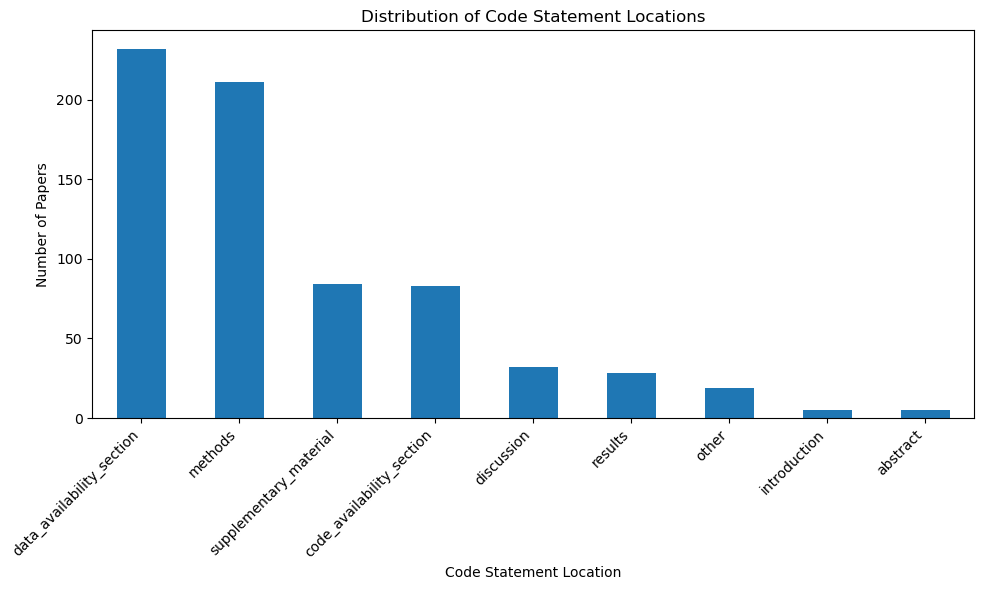

In [33]:
# --- Flatten code_statement_locations ---
locations = (
    df_inscope["code_statement_locations"]
    .dropna()
    .explode()
)

counts = locations.value_counts()

# --- Plot ---
plt.figure(figsize=(10, 6))
counts.plot(kind="bar")
plt.ylabel("Number of Papers")
plt.xlabel("Code Statement Location")
plt.title("Distribution of Code Statement Locations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [34]:
n_locations = (
    df_inscope["code_statement_locations"]
    .apply(lambda x: 0 if x is None else len(x))
)

counts = n_locations.value_counts().sort_index()
total = counts.sum()

summary = (
    counts.astype(str)
    + " ("
    + (counts / total * 100).round(1).astype(str)
    + "%)"
)

print(f"\nNumber of code statement locations per paper (n={total}):\n")
print(summary.to_string())


Number of code statement locations per paper (n=3967):

code_statement_locations
0    3445 (86.8%)
1      358 (9.0%)
2      152 (3.8%)
3       11 (0.3%)
4        1 (0.0%)


## Code Statement Sentence

In [35]:
df_inscope["code_statement_sentence"].value_counts(dropna=False)

code_statement_sentence
None                                                                                                            3445
The complete code used for model development and evaluation in this project is publicly available on GitHub:       8
The source code for preprocessing and analyzing the data is available on GitHub                                    3
The code to build and train the model is openly available on github.                                               2
The code used to conduct the analysis is available on GitHub                                                       2
                                                                                                                ... 
All statistical analyses were performed using R software [24]. The R source code is available online at            1
The source code for this study is provided on GitHub                                                               1
The code is in the Source code.zip file.

## Country of Origin

In [37]:
# some names are redundant or inconsistent; normalize them

COUNTRY_NORMALIZATION_MAP = {
    # Netherlands
    "the Netherlands": "Netherlands",
    "The Netherlands": "Netherlands",

    # United States
    "United States of America": "United States",

    # South Korea
    "Republic of Korea": "South Korea",
    "Korea, Republic of": "South Korea",

    # Iran
    "Iran, Islamic Republic of": "Iran",

    # Russia
    "Russian Federation": "Russia",

    # Turkey
    "Türkiye": "Turkey",

    # Optional ISO / spelling harmonization
    "Viet Nam": "Vietnam",
}

def normalize_country(x):
    if x is None:
        return None
    x = str(x).strip()
    if x.lower() == "not reported":
        return None
    return COUNTRY_NORMALIZATION_MAP.get(x, x)


df_inscope["country_first_author_institution_normalized"] = (
    df_inscope["country_first_author_institution"]
    .apply(normalize_country)
)

/var/folders/h6/z36012w55gz3qplddg4wtlf80000gn/T/ipykernel_60507/1429156246.py:37: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [38]:
df_inscope["country_first_author_institution_normalized"].value_counts(dropna=False)

country_first_author_institution_normalized
China             1286
United States      460
United Kingdom     362
Netherlands        324
Germany            157
                  ... 
Philippines          1
Peru                 1
Zimbabwe             1
Egypt                1
Uganda               1
Name: count, Length: 77, dtype: int64

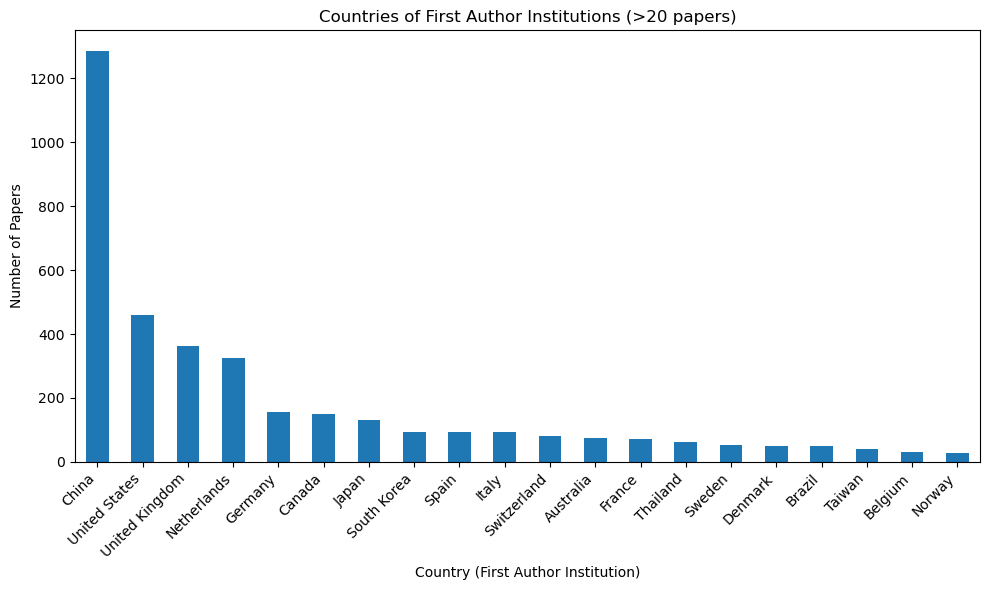

In [39]:
# Count countries
counts = (
    df_inscope["country_first_author_institution_normalized"]
    .dropna()
    .value_counts()
)

# Keep only countries with >20 rows
counts = counts[counts > 20]

# Plot
plt.figure(figsize=(10, 6))
counts.plot(kind="bar")
plt.ylabel("Number of Papers")
plt.xlabel("Country (First Author Institution)")
plt.title("Countries of First Author Institutions (>20 papers)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Code Sharing per Country of Origin

/var/folders/h6/z36012w55gz3qplddg4wtlf80000gn/T/ipykernel_60507/3449597472.py:44: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




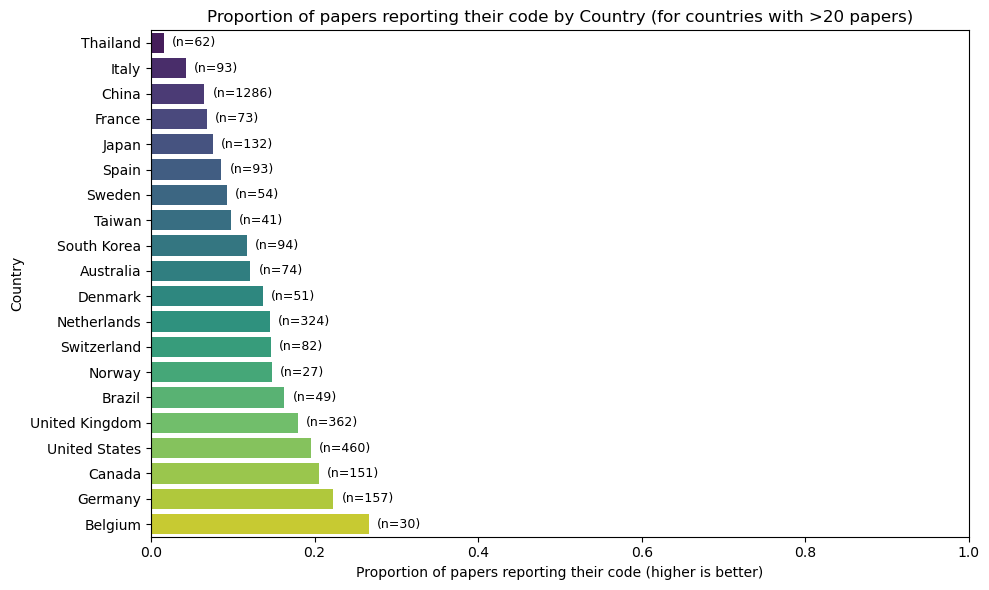

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Compute ratio of reporting code per country of origin
# ------------------------------------------------------------
country_col = (
    "country_first_author_institution_normalized"
    if "country_first_author_institution_normalized" in df_inscope.columns
    else "country_first_author_institution"
)

counts = df_inscope[country_col].value_counts()
valid_countries = counts[counts > 20].index

reported_mask = (
    df_inscope["repo_status"].isin(
        [RepoStatus.OK.value, RepoStatus.NOT_SUPPORTED.value]
    )
    | (df_inscope["repo_url"] == "Appendix")
)

ratio_df = (
    df_inscope[df_inscope[country_col].isin(valid_countries)]
    .assign(is_reported=reported_mask)
    .groupby(country_col, dropna=False)["is_reported"]
    .mean()  # proportion reporting
    .reset_index(name="reported_ratio")
)

support_df = (
    df_inscope[df_inscope[country_col].isin(valid_countries)]
    .groupby(country_col)
    .size()
    .reset_index(name="support")
)

# Sort ascending (increasing order of proportion reporting)
ratio_df = ratio_df.sort_values("reported_ratio", ascending=True)
ratio_df = ratio_df.merge(support_df, on=country_col, how="left")

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ratio_df,
    x="reported_ratio",
    y=country_col,
    palette="viridis"
)
ax = plt.gca()

for i, row in ratio_df.iterrows():
    ax.text(
        row["reported_ratio"] + 0.01,
        i,
        f"(n={row['support']})",
        va="center",
        fontsize=9,
        color="black"
    )

plt.xlabel("Proportion of papers reporting their code (higher is better)")
plt.ylabel("Country")
plt.title("Proportion of papers reporting their code by Country (for countries with >20 papers)")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Aggregate per journal

/var/folders/h6/z36012w55gz3qplddg4wtlf80000gn/T/ipykernel_60507/639134975.py:37: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




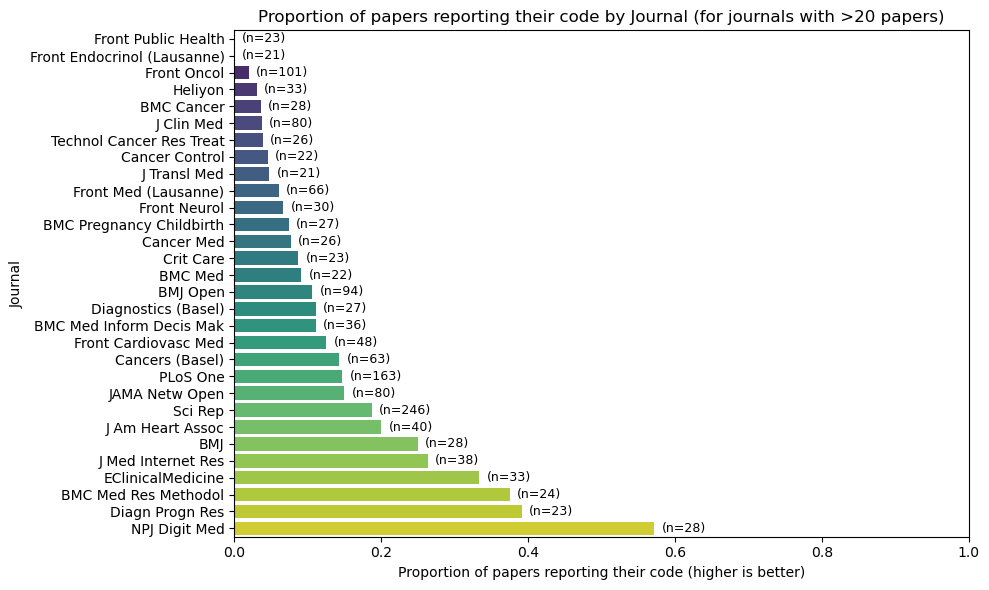

In [ ]:
# Compute ratio of non-empty repo_url per Journal/Book
counts = df_inscope["Journal/Book"].value_counts()
valid_journals = counts[counts > 20].index

reported_mask = (
    df_inscope["repo_status"].isin(
        [RepoStatus.OK.value, RepoStatus.NOT_SUPPORTED.value]
    )
    | (df_inscope["repo_url"] == "Appendix")
)

ratio_df = (
    df_inscope[df_inscope["Journal/Book"].isin(valid_journals)]
    .assign(is_reported=reported_mask)
    .groupby("Journal/Book", dropna=False)["is_reported"]
    .mean()  # proportion reporting
    .reset_index(name="reported_ratio")
)

support_df = (
    df_inscope[df_inscope["Journal/Book"].isin(valid_journals)]
    .groupby("Journal/Book")
    .size()
    .reset_index(name="support")
)

# Sort ascending (increasing order of proportion reporting)
ratio_df = ratio_df.sort_values("reported_ratio", ascending=True)
ratio_df = ratio_df.merge(support_df, on="Journal/Book", how="left")

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ratio_df,
    x="reported_ratio",
    y="Journal/Book",
    palette="viridis"
)
ax = plt.gca()

for i, row in ratio_df.iterrows():
    ax.text(
        row["reported_ratio"] + 0.01,  # slightly to the right of the bar
        i,
        f"(n={row['support']})",
        va="center",
        fontsize=9,
        color="black"
    )
plt.xlabel("Proportion of papers reporting their code (higher is better)")
plt.ylabel("Journal")
plt.title("Proportion of papers reporting their code by Journal (for journals with >20 papers)")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Proportion of Papers Reporting Their Code Per Year

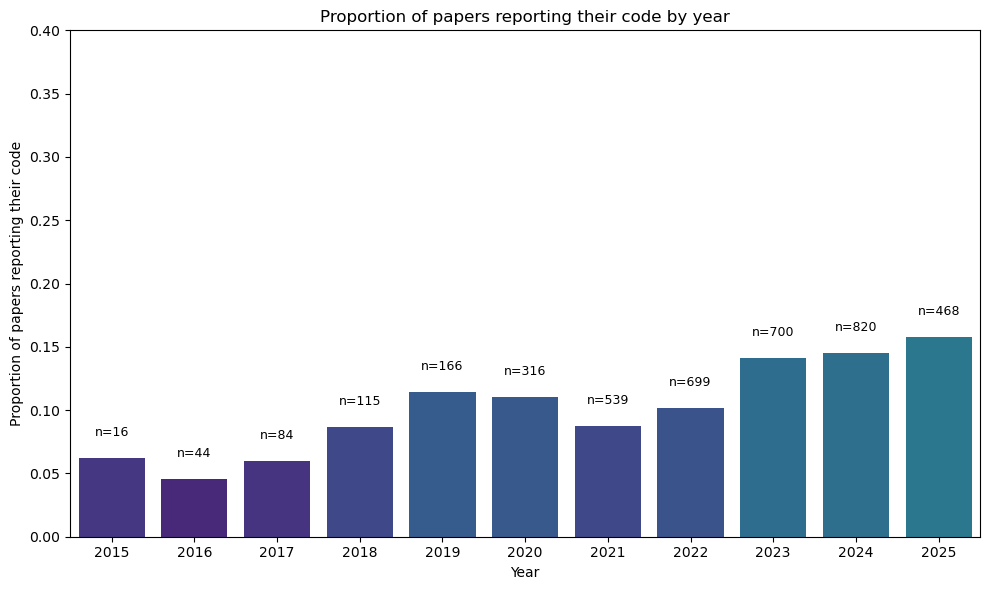

In [45]:
# ------------------------------------------------------------------
# Prepare year column
# ------------------------------------------------------------------
df_plot = df_inscope.copy()

df_plot["Create Date"] = pd.to_datetime(
    df_plot["Create Date"], format="%Y/%m/%d", errors="coerce"
)
df_plot["year"] = df_plot["Create Date"].dt.year

# Optional: drop rows with missing year
df_plot = df_plot[df_plot["year"].notna()]

# ------------------------------------------------------------------
# Define reporting condition
# ------------------------------------------------------------------
df_plot["is_reported"] = (
    df_plot["repo_status"].isin(
        [RepoStatus.OK.value, RepoStatus.NOT_SUPPORTED.value]
    )
    | (df_plot["repo_url"] == "Appendix")
)

# ------------------------------------------------------------------
# Aggregate by year
# ------------------------------------------------------------------
year_df = (
    df_plot
    .groupby("year", dropna=False)
    .agg(
        reported_ratio=("is_reported", "mean"),
        support=("is_reported", "size"),
    )
    .reset_index()
    .sort_values("year")
)

# ------------------------------------------------------------------
# Plot (vertical bars, color by height)
# ------------------------------------------------------------------
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=year_df,
    x="year",
    y="reported_ratio",
    color="lightgray"  # placeholder; overridden below
)

# Color bars based on reported_ratio
norm = mpl.colors.Normalize(vmin=0, vmax=0.4)
cmap = mpl.cm.viridis

for bar, value in zip(ax.patches, year_df["reported_ratio"]):
    bar.set_facecolor(cmap(norm(value)))

# ------------------------------------------------------------------
# Add support labels on top of bars
# ------------------------------------------------------------------
for i, row in year_df.iterrows():
    ax.text(
        i,
        row["reported_ratio"] + 0.015,
        f"n={int(row['support'])}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ------------------------------------------------------------------
# Final formatting (NO colorbar)
# ------------------------------------------------------------------
ax.set_ylim(0, 0.4)
ax.set_xlabel("Year")
ax.set_ylabel("Proportion of papers reporting their code")
ax.set_title("Proportion of papers reporting their code by year")

plt.tight_layout()
plt.show()

## Repository Assessment

In [51]:
df = df_repo_assessment[df_repo_assessment["repo_status"] == RepoStatus.OK]

# ------------------------------------------------------------
# 1. Define repo-quality boolean columns
# ------------------------------------------------------------
base_cols = [
    "contains_license",
    "sufficient_code_documentation",
    "is_modular_and_structured",
    "implements_tests",
    "fixes_seed_if_stochastic",
    "lists_hardware_requirements",
    "contains_link_to_paper",
    "contains_citation",
    "includes_data_or_sample",
]

# Only keep columns that actually exist
base_cols = [c for c in base_cols if c in df.columns]

# Global denominator: evaluated repositories
N = len(df)

# ------------------------------------------------------------
# 2. Build plotting rows
# ------------------------------------------------------------
plot_rows = []

# Regular criteria
for col in base_cols:
    evaluated = df[col].notna().sum()
    if evaluated == 0:
        continue

    pct_true = 100 * df.loc[df[col].notna(), col].astype(bool).sum() / N

    plot_rows.append({
        "criterion": col,
        "value": pct_true,
        "segment": "True",
        "text": ""
    })

# ------------------------------------------------------------
# README conditional bar
# ------------------------------------------------------------
readme_present = df["contains_readme"] == True

readme_complete = (
    readme_present
    & (df["readme_purpose_and_outputs"] == True)
)

readme_incomplete = (
    readme_present
    & (df["readme_purpose_and_outputs"] == False)
)

plot_rows.extend([
    {
        "criterion": "contains_readme",
        "value": 100 * readme_incomplete.sum() / N,
        "segment": "Incomplete README",
        "text": "Incomplete"
    },
    {
        "criterion": "contains_readme",
        "value": 100 * readme_complete.sum() / N,
        "segment": "Purpose & outputs",
        "text": "Complete"
    }
])

# ------------------------------------------------------------
# Requirements conditional bar (FIXED)
# ------------------------------------------------------------
req_present = df["contains_requirements"] == True

req_complete = (
    req_present
    & (df["requirements_dependency_versions"] == True)
)

req_incomplete = (
    req_present
    & (df["requirements_dependency_versions"] == False)
)

plot_rows.extend([
    {
        "criterion": "contains_requirements",
        "value": 100 * req_incomplete.sum() / N,
        "segment": "Incomplete dependencies",
        "text": "Not versioned"
    },
    {
        "criterion": "contains_requirements",
        "value": 100 * req_complete.sum() / N,
        "segment": "Versioned dependencies",
        "text": "Versioned"
    }
])

plot_df = pd.DataFrame(plot_rows)

# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
fig = px.bar(
    plot_df,
    x="criterion",
    y="value",
    color="segment",
    text="text",
    title=f"Code Sharing Practices (n={N})",
    labels={
        "criterion": "Repository Quality Criterion",
        "value": "Percentage of Repositories (%)"
    },
    color_discrete_map={
        "True": "#636EFA",
        "Incomplete README": "#EF553B",
        "Purpose & outputs": "#00CC96",
        "Incomplete dependencies": "#EF553B",
        "Versioned dependencies": "#00CC96",
    }
)

pretty = lambda s: s.replace("_", " ").title()

fig.update_xaxes(
    tickvals=plot_df["criterion"].unique(),
    ticktext=[pretty(c) for c in plot_df["criterion"].unique()],
    tickangle=45
)

fig.update_traces(
    textposition="inside",
    insidetextanchor="middle"
)

fig.update_layout(
    barmode="stack",
    width=1100,
    height=500,
    showlegend=False,
    yaxis_range=[0, 100]
)

fig.show()

## Comparing Journals' code sharing practices

In [59]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# ------------------------------------------------------------
# 1) Filter to OK repositories
# ------------------------------------------------------------
df = df_repo_assessment[df_repo_assessment["repo_status"] == RepoStatus.OK].copy()

journal_col = "Journal/Book"

criteria = [
    "is_empty",
    "contains_readme",
    "contains_requirements",
    "contains_license",
    "sufficient_code_documentation",
    "is_modular_and_structured",
    "implements_tests",
    "fixes_seed_if_stochastic",
    "lists_hardware_requirements",
    "contains_link_to_paper",
    "contains_citation",
    "includes_data_or_sample",
]
criteria = [c for c in criteria if c in df.columns]

# Clean journals
df[journal_col] = df[journal_col].astype("string").str.strip()
df = df.dropna(subset=[journal_col])

# Coerce criteria to numeric 0/1 (robust to bool/object/"True"/"False")
for c in criteria:
    df[c] = df[c].replace({True: 1, False: 0, "True": 1, "False": 0})
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ------------------------------------------------------------
# 2) Global mean per criterion (red dots)
# ------------------------------------------------------------
global_mean = df[criteria].mean()

# ------------------------------------------------------------
# 3) Journal means (grey dots) for journals with >10 papers
# ------------------------------------------------------------
journal_n = df[journal_col].value_counts()
valid_journals = journal_n[journal_n > 10].index

df_j = df[df[journal_col].isin(valid_journals)].copy()

journal_mean_long = (
    df_j.groupby(journal_col)[criteria]
      .mean()
      .stack()
      .rename("mean")
      .reset_index()
      .rename(columns={"level_1": "criterion"})
)

journal_mean_long["n_in_journal"] = journal_mean_long[journal_col].map(journal_n)
journal_mean_long = journal_mean_long.dropna(subset=["mean"])

# Deterministic x-jitter so dots don't overlap perfectly
crit_to_x = {c: i for i, c in enumerate(criteria)}
journal_mean_long["x"] = journal_mean_long["criterion"].map(crit_to_x).astype(float)

h = pd.util.hash_pandas_object(journal_mean_long[journal_col].astype(str), index=False).astype(np.int64)
journal_mean_long["xj"] = journal_mean_long["x"] + (((h % 10_000) / 10_000.0) - 0.5) * 0.5  # +/-0.25

# ------------------------------------------------------------
# 4) Plot
# ------------------------------------------------------------
fig = go.Figure()

# Grey dots: journal means
fig.add_trace(
    go.Scatter(
        x=journal_mean_long["xj"],
        y=journal_mean_long["mean"],
        mode="markers",
        marker=dict(color="grey", size=7),
        name="Journal mean (n>10)",
        hovertemplate=(
            "Journal: %{customdata[0]}<br>"
            "n: %{customdata[1]}<br>"
            "Criterion: %{customdata[2]}<br>"
            "Mean: %{y:.2f}<extra></extra>"
        ),
        customdata=np.stack(
            [
                journal_mean_long[journal_col].astype(str),
                journal_mean_long["n_in_journal"].astype(int),
                journal_mean_long["criterion"].astype(str),
            ],
            axis=1,
        ),
    )
)

# Red dots: global means
fig.add_trace(
    go.Scatter(
        x=[crit_to_x[c] for c in criteria],
        y=[global_mean[c] for c in criteria],
        mode="markers",
        marker=dict(color="red", size=10),
        name="Global mean",
        hovertemplate="Criterion: %{text}<br>Global mean: %{y:.3f}<extra></extra>",
        text=criteria,
    )
)

pretty = lambda s: s.replace("_", " ").title()

fig.update_layout(
    title="Repo Practices by Journal (RepoStatus.OK; grey=journal mean for journals with >10 papers; red=global mean)",
    xaxis=dict(
        title="Criterion",
        tickmode="array",
        tickvals=list(range(len(criteria))),
        ticktext=[pretty(c) for c in criteria],
        tickangle=45,
    ),
    yaxis=dict(title="Score (0/1)", range=[-0.05, 1.05]),
    width=1300,
    height=600,
)

fig.show()

# Quick sanity checks
print("Journals with >10 OK repos:", len(valid_journals))
print("Grey points plotted:", len(journal_mean_long))

/var/folders/h6/z36012w55gz3qplddg4wtlf80000gn/T/ipykernel_60507/2292811175.py:34: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Journals with >10 OK repos: 4
Grey points plotted: 48


In [68]:
import pandas as pd

# ------------------------------------------------------------
# 1) Filter to OK repositories
# ------------------------------------------------------------
df = df_repo_assessment[df_repo_assessment["repo_status"] == RepoStatus.OK].copy()

journal_col = "Journal/Book"

criteria = [
    "is_empty",
    "contains_readme",
    "contains_requirements",
    "contains_license",
    "sufficient_code_documentation",
    "is_modular_and_structured",
    "implements_tests",
    "fixes_seed_if_stochastic",
    "lists_hardware_requirements",
    "contains_link_to_paper",
    "contains_citation",
    "includes_data_or_sample",
]
criteria = [c for c in criteria if c in df.columns]

# Clean journals
df[journal_col] = df[journal_col].astype("string").str.strip()
df = df.dropna(subset=[journal_col])

# Coerce criteria to numeric 0/1 (robust to bool/object/"True"/"False")
for c in criteria:
    df[c] = df[c].replace({True: 1, False: 0, "True": 1, "False": 0})
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ------------------------------------------------------------
# 2) Flip is_empty -> non_empty (higher = better)
# ------------------------------------------------------------
if "is_empty" in criteria:
    df["non_empty"] = 1 - df["is_empty"]
    criteria = ["non_empty"] + [c for c in criteria if c != "is_empty"]

# ------------------------------------------------------------
# 3) Global mean per criterion
# ------------------------------------------------------------
global_mean = df[criteria].mean()

# ------------------------------------------------------------
# 4) Journal means (only journals with support > 5)
# ------------------------------------------------------------
journal_n = df[journal_col].value_counts()
valid_journals = journal_n[journal_n > 5].index

journal_means = (
    df[df[journal_col].isin(valid_journals)]
    .groupby(journal_col)[criteria]
    .mean()
)

# ------------------------------------------------------------
# 5) Rank journals by sum of (journal_mean - global_mean)
# ------------------------------------------------------------
diff = journal_means.sub(global_mean, axis="columns")

ranking_df = (
    pd.DataFrame({
        "support": journal_n.loc[valid_journals],
        "sum_diff": diff.sum(axis=1),           # positive = above global overall
        "sum_abs_diff": diff.abs().sum(axis=1), # magnitude of deviation overall
    })
    .sort_values("sum_diff", ascending=False)
    .join(diff.add_prefix("diff_"))
)

display(ranking_df)

/var/folders/h6/z36012w55gz3qplddg4wtlf80000gn/T/ipykernel_60507/3360005810.py:32: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,support,sum_diff,sum_abs_diff,diff_non_empty,diff_contains_readme,diff_contains_requirements,diff_contains_license,diff_sufficient_code_documentation,diff_is_modular_and_structured,diff_implements_tests,diff_fixes_seed_if_stochastic,diff_lists_hardware_requirements,diff_contains_link_to_paper,diff_contains_citation,diff_includes_data_or_sample
Journal/Book,,,,,,,,,,,,,,,
Diagn Progn Res,7,1.662903,2.087715,0.063158,0.033459,0.049624,0.224060,0.509774,0.113534,-0.036842,0.218918,-0.063158,0.478195,-0.112406,0.184586
PLOS Digit Health,8,1.323617,1.805331,0.063158,0.176316,0.371053,-0.097368,0.027632,0.292105,0.213158,-0.138225,0.061842,0.121053,-0.005263,0.238158
BMC Med Res Methodol,8,0.823617,1.999933,-0.061842,-0.073684,0.371053,-0.347368,0.277632,0.167105,-0.036842,0.361775,-0.063158,0.121053,-0.005263,0.113158
JAMA Netw Open,9,0.615284,1.227991,0.063158,0.176316,0.065497,0.097076,0.097076,-0.013450,0.074269,-0.082670,0.047953,-0.045614,0.300292,-0.164620
BMJ Open,9,0.304172,0.721131,-0.047953,0.065205,0.065497,-0.014035,0.097076,-0.013450,-0.036842,0.161775,-0.063158,0.065497,-0.033041,0.057602
PLoS Med,9,0.059728,1.969512,0.063158,-0.157018,-0.378947,-0.014035,0.097076,0.097661,-0.036842,-0.304892,-0.063158,0.287719,0.078070,0.390936
Sci Rep,39,0.006309,0.633840,-0.013765,-0.003171,0.056950,0.062888,-0.065317,-0.021997,-0.036842,0.111775,0.039406,-0.071255,-0.101417,0.049055
NPJ Digit Med,16,-0.155550,0.879234,0.000658,0.051316,0.121053,-0.034868,-0.097368,0.042105,0.088158,-0.054892,-0.063158,0.058553,-0.130263,-0.136842
EClinicalMedicine,11,-0.392292,0.953162,-0.027751,-0.005502,0.075598,-0.256459,-0.165550,-0.094258,-0.036842,0.111775,-0.063158,0.075598,0.017464,-0.023206
